# Path-CBRP time sweep: profit shortfall vs budget

This notebook reads sweep CSVs from the parent directory (`external/CBRP_original/`) and plots a **custom profit gap** (not CPLEX `relativeGAP`).

## Reference profit \(P^\*\) (per CSV file)

1. If any row has `terminal == "all_positive_profit_blocks"`, then \(P^\* = \max(\text{cost})\) over those rows.
2. Else (e.g. sweep stopped on `max_T` while already serving all positive-profit blocks): \(P^\* = \max(\text{cost})\) over rows with `num_serviced_blocks == num_positive_profit_blocks`.
3. Else: \(P^\* = \max(\text{cost})\) over the whole file and a **warning** is printed (degenerate case).

Example: `notified-alto-santo-1000-2019.csv` ends with `terminal=max_T` but the last rows already achieve full positive coverage; rule (2) still yields the same \(P^\*\) as the plateau profit.

## Profit gap (per row)

For row profit \(P_t = \text{cost}\):

$$\text{profit\_gap} = \frac{P^* - P_t}{P^*} \quad \text{(NaN if } P^*=0\text{)}$$

Rows with `terminal == "error"` are excluded from aggregation plots.

## Aggregation

- **Binned curve (default):** 5-minute bins on `budget_T`, mean (and std band) of `profit_gap` across all instance-rows in each bin.
- **Exact-T curve:** mean gap only at `budget_T` values that appear in at least `MIN_FILES` CSVs (reduces sparse noise).

In [8]:
import re
import warnings
from pathlib import Path
from typing import List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# CSVs live next to this reports/ folder
DATA_DIR = Path("..").resolve()
GLOB_PATTERN = "notified-alto-santo-*.csv"
#GLOB_PATTERN = "brkga-notified-limoeiro-*.csv"
BIN_MINUTES = 5.0
MIN_FILES_FOR_EXACT_T = 3

In [9]:
STEM_RE = re.compile(
    r"^notified-alto-santo-(?P<size>1000|2000|3000)-(?P<year>20\d{2})\.csv$"
    #r"^brkga-notified-limoeiro-(?P<size>1000|2000|3000)-(?P<year>20\d{2})\.csv$"
)


def parse_stem(path: Path) -> Optional[Tuple[str, str]]:
    m = STEM_RE.match(path.name)
    if not m:

        return None
    return m.group("size"), m.group("year")


def reference_profit(df: pd.DataFrame, stem: str) -> Tuple[float, str]:
    """Return (P_star, rule_name)."""
    cost = pd.to_numeric(df["cost"], errors="coerce")
    df = df.assign(_cost=cost)
    ok = df[df["terminal"] == "all_positive_profit_blocks"]
    if len(ok) > 0:
        return float(ok["_cost"].max()), "terminal_success"
    mask_full = df["num_serviced_blocks"] == df["num_positive_profit_blocks"]
    sub = df[mask_full]
    if len(sub) > 0:
        return float(sub["_cost"].max()), "max_cost_when_fully_positive"
    warnings.warn(f"{stem}: no success row; P* = max(cost) over entire file")
    return float(df["_cost"].max()), "max_cost_fallback"


def load_sweep_csvs(data_dir: Path) -> pd.DataFrame:
    paths = sorted(data_dir.glob(GLOB_PATTERN))
    frames: List[pd.DataFrame] = []
    for p in paths:
        meta = parse_stem(p)
        if meta is None:
            continue
        size, year = meta
        raw = pd.read_csv(p)
        p_star, rule = reference_profit(raw, p.name)
        raw["source_file"] = p.name
        raw["size"] = size
        raw["year"] = int(year)
        raw["P_star"] = p_star
        raw["P_star_rule"] = rule
        frames.append(raw)
    if not frames:
        raise FileNotFoundError(f"No CSVs matching {GLOB_PATTERN} under {data_dir}")
    out = pd.concat(frames, ignore_index=True)
    return out


df_raw = load_sweep_csvs(DATA_DIR)
print(f"Loaded {df_raw['source_file'].nunique()} files, {len(df_raw)} rows")
print(df_raw.groupby("source_file")["P_star"].first().sort_index().to_string())

Loaded 18 files, 242 rows
source_file
notified-alto-santo-1000-2016.csv     180.0
notified-alto-santo-1000-2017.csv     939.0
notified-alto-santo-1000-2018.csv     947.0
notified-alto-santo-1000-2019.csv     947.0
notified-alto-santo-1000-2020.csv     982.0
notified-alto-santo-1000-2021.csv    1056.0
notified-alto-santo-2000-2016.csv     126.0
notified-alto-santo-2000-2017.csv     832.0
notified-alto-santo-2000-2018.csv     832.0
notified-alto-santo-2000-2019.csv     832.0
notified-alto-santo-2000-2020.csv     861.0
notified-alto-santo-2000-2021.csv     945.0
notified-alto-santo-3000-2016.csv     163.0
notified-alto-santo-3000-2017.csv     952.0
notified-alto-santo-3000-2018.csv     952.0
notified-alto-santo-3000-2019.csv     952.0
notified-alto-santo-3000-2020.csv     988.0
notified-alto-santo-3000-2021.csv    1095.0


In [10]:
df = df_raw.copy()
df["P_t"] = pd.to_numeric(df["cost"], errors="coerce")
df = df[df["terminal"] != "error"].copy()

df["profit_gap"] = np.where(
    df["P_star"] > 0,
    (df["P_star"] - df["P_t"]) / df["P_star"],
    np.nan,
)
# Numerical noise: clip tiny negatives to 0
df["profit_gap"] = df["profit_gap"].clip(lower=0.0)

df["budget_bin"] = (np.floor(df["budget_T"] / BIN_MINUTES) * BIN_MINUTES).astype(float)

df[["budget_T", "P_t", "P_star", "profit_gap", "terminal", "source_file", "size", "year"]].head(12)

,budget_T,P_t,P_star,profit_gap,terminal,source_file,size,year
0,5.0,54.0,180.0,0.700000,NaN,notified-alto-santo-1000-2016.csv,1000,2016
1,10.0,96.0,180.0,0.466667,NaN,notified-alto-santo-1000-2016.csv,1000,2016
2,15.0,120.0,180.0,0.333333,NaN,notified-alto-santo-1000-2016.csv,1000,2016
3,20.0,144.0,180.0,0.200000,NaN,notified-alto-santo-1000-2016.csv,1000,2016
4,25.0,164.0,180.0,0.088889,NaN,notified-alto-santo-1000-2016.csv,1000,2016
5,30.0,176.0,180.0,0.022222,NaN,notified-alto-santo-1000-2016.csv,1000,2016
6,35.0,180.0,180.0,0.000000,all_positive_profit_blocks,notified-alto-santo-1000-2016.csv,1000,2016
7,5.0,208.0,939.0,0.778488,NaN,notified-alto-santo-1000-2017.csv,1000,2017
8,10.0,345.0,939.0,0.632588,NaN,notified-alto-santo-1000-2017.csv,1000,2017
9,15.0,462.0,939.0,0.507987,NaN,notified-alto-santo-1000-2017.csv,1000,2017


In [11]:
# Binned aggregation (all instances pooled)
g_bin = (
    df.groupby("budget_bin", as_index=False)
    .agg(mean_gap=("profit_gap", "mean"), std_gap=("profit_gap", "std"), n=("profit_gap", "size"))
    .sort_values("budget_bin")
)
g_bin["std_gap"] = g_bin["std_gap"].fillna(0.0)

# Exact budget_T: only T observed in >= MIN_FILES_FOR_EXACT_T CSVs
vc = df.groupby("budget_T")["source_file"].nunique()
common_T = vc[vc >= MIN_FILES_FOR_EXACT_T].index
g_exact = (
    df[df["budget_T"].isin(common_T)]
    .groupby("budget_T", as_index=False)
    .agg(mean_gap=("profit_gap", "mean"), std_gap=("profit_gap", "std"), n_files=("source_file", "nunique"))
    .sort_values("budget_T")
)
g_exact["std_gap"] = g_exact["std_gap"].fillna(0.0)

print(f"Exact-T points with >= {MIN_FILES_FOR_EXACT_T} files: {len(g_exact)}")

Exact-T points with >= 3 files: 15


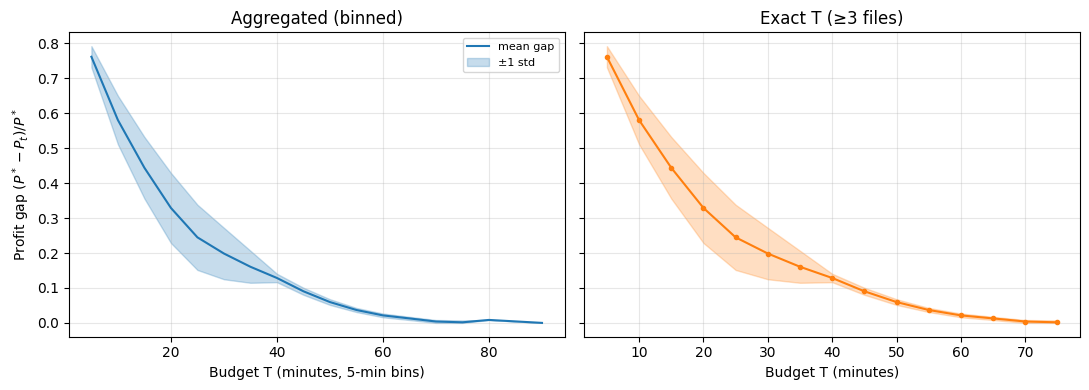

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

ax = axes[0]
ax.plot(g_bin["budget_bin"], g_bin["mean_gap"], color="C0", label="mean gap")
ax.fill_between(
    g_bin["budget_bin"],
    (g_bin["mean_gap"] - g_bin["std_gap"]).clip(0, None),
    g_bin["mean_gap"] + g_bin["std_gap"],
    alpha=0.25,
    color="C0",
    label="±1 std",
)
ax.set_xlabel("Budget T (minutes, 5-min bins)")
ax.set_ylabel("Profit gap $(P^* - P_t) / P^*$")
ax.set_title("Aggregated (binned)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=8)

ax = axes[1]
ax.plot(g_exact["budget_T"], g_exact["mean_gap"], "o-", color="C1", markersize=3, label="mean gap")
ax.fill_between(
    g_exact["budget_T"],
    (g_exact["mean_gap"] - g_exact["std_gap"]).clip(0, None),
    g_exact["mean_gap"] + g_exact["std_gap"],
    alpha=0.25,
    color="C1",
)
ax.set_xlabel("Budget T (minutes)")
ax.set_title(f"Exact T (≥{MIN_FILES_FOR_EXACT_T} files)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

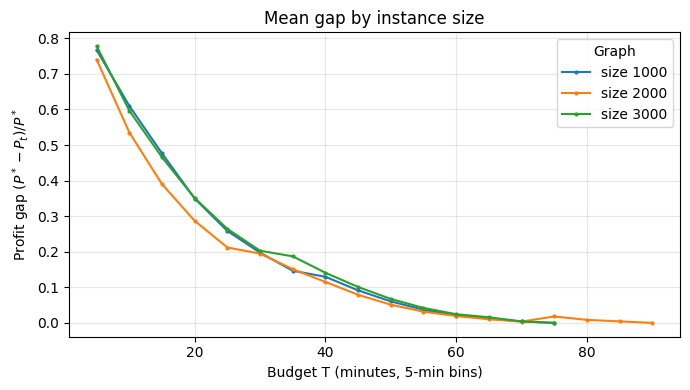

In [ ]:
# Facet: one line per graph size (1000 / 2000 / 3000), binned mean gap
fig, ax = plt.subplots(figsize=(7, 4))
for sz, sub in df.groupby("size"):
    gb = (
        sub.groupby("budget_bin", as_index=False)
        .agg(mean_gap=("profit_gap", "mean"))
        .sort_values("budget_bin")
    )
    ax.plot(gb["budget_bin"], gb["mean_gap"], marker="o", markersize=2, label=f"size {sz}")

ax.set_xlabel("Budget T (minutes, 5-min bins)")
ax.set_ylabel("Profit gap $(P^* - P_t) / P^*$")
ax.set_title("Mean gap by instance size")
ax.grid(True, alpha=0.3)
ax.legend(title="Graph")
plt.tight_layout()


In [ ]:
plt.show()

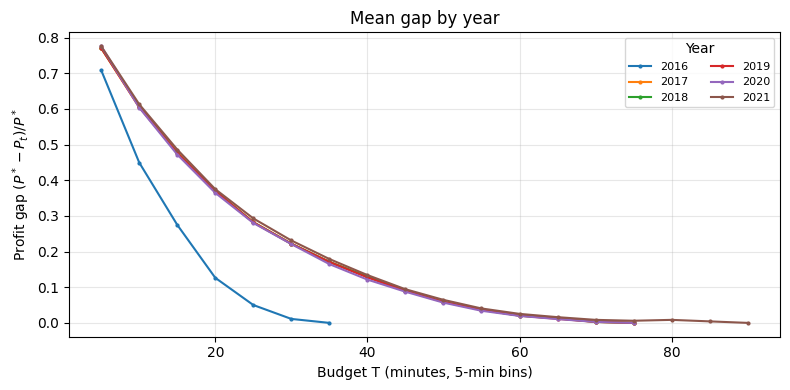

In [14]:
# Optional: mean gap by calendar year (3 instances per year)
fig, ax = plt.subplots(figsize=(8, 4))
for yr, sub in df.groupby("year"):
    gb = (
        sub.groupby("budget_bin", as_index=False)
        .agg(mean_gap=("profit_gap", "mean"))
        .sort_values("budget_bin")
    )
    ax.plot(gb["budget_bin"], gb["mean_gap"], marker="o", markersize=2, label=str(yr))

ax.set_xlabel("Budget T (minutes, 5-min bins)")
ax.set_ylabel("Profit gap $(P^* - P_t) / P^*$")
ax.set_title("Mean gap by year")
ax.grid(True, alpha=0.3)
ax.legend(title="Year", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Serviced blocks vs budget T (aggregated across sweep CSVs)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

g_bin_srv = (
    df.groupby("budget_bin", as_index=False)
    .agg(
        mean_srv=("num_serviced_blocks", "mean"),
        std_srv=("num_serviced_blocks", "std"),
    )
    .sort_values("budget_bin")
)
g_bin_srv["std_srv"] = g_bin_srv["std_srv"].fillna(0.0)

ax = axes[0]
ax.plot(g_bin_srv["budget_bin"], g_bin_srv["mean_srv"], color="C2", label="mean")
ax.fill_between(
    g_bin_srv["budget_bin"],
    (g_bin_srv["mean_srv"] - g_bin_srv["std_srv"]).clip(0, None),
    g_bin_srv["mean_srv"] + g_bin_srv["std_srv"],
    alpha=0.25,
    color="C2",
    label="±1 std",
)
ax.set_xlabel("Budget T (minutes, 5-min bins)")
ax.set_ylabel("Serviced blocks (count)")
ax.set_title("Aggregated (binned)")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=8)

vc_srv = df.groupby("budget_T")["source_file"].nunique()
common_T_srv = vc_srv[vc_srv >= MIN_FILES_FOR_EXACT_T].index
g_exact_srv = (
    df[df["budget_T"].isin(common_T_srv)]
    .groupby("budget_T", as_index=False)
    .agg(
        mean_srv=("num_serviced_blocks", "mean"),
        std_srv=("num_serviced_blocks", "std"),
    )
    .sort_values("budget_T")
)
g_exact_srv["std_srv"] = g_exact_srv["std_srv"].fillna(0.0)

ax = axes[1]
ax.plot(g_exact_srv["budget_T"], g_exact_srv["mean_srv"], "o-", color="C3", markersize=3)
ax.fill_between(
    g_exact_srv["budget_T"],
    (g_exact_srv["mean_srv"] - g_exact_srv["std_srv"]).clip(0, None),
    g_exact_srv["mean_srv"] + g_exact_srv["std_srv"],
    alpha=0.25,
    color="C3",
)
ax.set_xlabel("Budget T (minutes)")
ax.set_title(f"Exact T (≥{MIN_FILES_FOR_EXACT_T} files)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Notes

- CPLEX column `relativeGAP` is left unused; the plotted gap is **economic** relative to \(P^\*\) from the rules above.
- If you add more sweep CSVs, widen `STEM_RE` or relax `parse_stem` accordingly.